## Load dataset

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql import functions as F
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg, col, lag, count
from pyspark.sql.window import Window
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

In [2]:
spark = SparkSession.builder.appName("FlightProject").getOrCreate()

df = spark.read.parquet("/Users/huynhphuongchi/Desktop/Unipi/Distributed data Analysis and Mining/flights_cleaned_full.parquet")
df.createOrReplaceTempView("flight_cleaned")

df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 22:33:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/16 22:33:22 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


root
 |-- FL_DATE: date (nullable = true)
 |-- AIRLINE_CODE: string (nullable = true)
 |-- DOT_CODE: integer (nullable = true)
 |-- FL_NUMBER: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: integer (nullable = true)
 |-- DEP_TIME: double (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- WHEELS_OFF: double (nullable = true)
 |-- WHEELS_ON: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- CRS_ARR_TIME: integer (nullable = true)
 |-- ARR_TIME: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- ELAPSED_TIME: double (nullable = true)
 |-- AIR_TIME: double (nullable = true)
 |-- DISTANCE: double (nullable = true)
 |-- DELAY_DUE_CARRIER: integer (nullable = true)
 |-- DELAY_DUE_WEATHER: integer (nullable = true)
 |-- DELAY_DUE_NAS: integer (nullable = true)
 |-- DELAY_DUE_SECURITY: 

26/03/16 22:33:25 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [3]:
df = df.repartition(40)
spark.conf.set("spark.sql.shuffle.partitions", 40)

In [4]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

26/03/16 22:33:25 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [ ]:
#PREVIOUS_FLIGHT_DELAY
window_spec=Window.partitionBy("AIRLINE_CODE","ROUTE").orderBy("FL_DATE","CRS_DEP_TIME")
df=df.withColumn("PREVIOUS_FLIGHT_DELAY",lag("ARR_DELAY").over(window_spec))
df=df.fillna({"PREVIOUS_FLIGHT_DELAY":0})

In [7]:
#AIRPORT_CONGESTION
airport_congestion=df.groupBy("ORIGIN","FL_DATE","Hour").agg(count("*").alias("AIRPORT_CONGESTION"))
df=df.join(airport_congestion,["ORIGIN","FL_DATE","Hour"],"left")

avg_congestion = airport_congestion.groupBy("ORIGIN").agg(
    avg("AIRPORT_CONGESTION").alias("AVG_CONGESTION"))
df=df.join(avg_congestion,"ORIGIN")

df = df.withColumn(
    "CONGESTION_RATIO",
    col("AIRPORT_CONGESTION") / col("AVG_CONGESTION")
)

# Train/Test split

In [8]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

In [9]:
# we used ARR_DELAY as a target to predict
df.select("ARR_DELAY").describe().show() # Distribution of delay minutes

+-------+-----------------+
|summary|        ARR_DELAY|
+-------+-----------------+
|  count|          1931907|
|   mean|  3.0066851044072|
| stddev|39.98633059579589|
|    min|           -119.0|
|    max|            599.0|
+-------+-----------------+



# Pre-processing

In [ ]:
airline_delay = train_df.groupBy("AIRLINE_CODE").agg(avg("DELAYED").alias("AIRLINE_DELAY_RATE"))
airport_delay = train_df.groupBy("ORIGIN").agg(avg("DELAYED").alias("AIRPORT_DELAY_RATE"))
route_delay = train_df.groupBy("ROUTE").agg(avg("DELAYED").alias("ROUTE_DELAY_RATE"))

In [11]:
train_df = train_df \
    .join(airport_delay, "ORIGIN", "left") \
    .join(airline_delay, "AIRLINE_CODE", "left") \
    .join(route_delay, "ROUTE", "left")

test_df = test_df \
    .join(airport_delay, "ORIGIN", "left") \
    .join(airline_delay, "AIRLINE_CODE", "left") \
    .join(route_delay, "ROUTE", "left")

In [ ]:
#fill NA, because test set may have new airport/airline/route
global_rate = train_df.select(avg("DELAYED")).first()[0]

train_df = train_df.fillna({"AIRLINE_DELAY_RATE": global_rate, "AIRPORT_DELAY_RATE": global_rate,"ROUTE_DELAY_RATE": global_rate})
test_df = train_df.fillna({
    "AIRLINE_DELAY_RATE": global_rate,
    "AIRPORT_DELAY_RATE": global_rate,
    "ROUTE_DELAY_RATE": global_rate
})

In [15]:
feature_cols = [
    "DISTANCE",
    "DEP_DELAY",
    "CRS_ELAPSED_TIME",
    "TAXI_OUT",
    "TAXI_IN",
    "Hour",
    "DayOfWeek",
    "Month",
    "AIRPORT_DELAY_RATE",
    "AIRLINE_DELAY_RATE",
    "ROUTE_DELAY_RATE",
    "PREVIOUS_FLIGHT_DELAY",
    "AIRPORT_CONGESTION"
]

In [16]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_df = assembler.transform(train_df)
test_df = assembler.transform(test_df)

In [17]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features"
)

scaler_model = scaler.fit(train_df)

train_df = scaler_model.transform(train_df)
test_df = scaler_model.transform(test_df)

# Linear Regression

In [18]:
lr = LinearRegression(
    labelCol="ARR_DELAY",
    featuresCol="scaled_features",
    maxIter=50,
    regParam=0.1
)

lr_model = lr.fit(train_df)

26/03/16 22:35:11 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/16 22:35:14 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [19]:
predictions = lr_model.transform(test_df)

predictions.select(
    "ARR_DELAY",
    "prediction"
).show(10)

+---------+-------------------+
|ARR_DELAY|         prediction|
+---------+-------------------+
|     -7.0| -16.74522934746056|
|     -3.0|-17.307855576488695|
|      1.0|-13.131017878499325|
|     -4.0|-10.457466817556465|
|      5.0| -3.400034581997337|
|    143.0| 140.89671276231618|
|     -6.0|-10.142099672429312|
|    -19.0|-16.236829835049637|
|    -22.0|-21.350537415204965|
|    -31.0| -22.02411924128938|
+---------+-------------------+
only showing top 10 rows


In [20]:
rmse_evaluator = RegressionEvaluator(
    labelCol="ARR_DELAY",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = rmse_evaluator.evaluate(predictions)

print("RMSE:", rmse)
mae_evaluator = RegressionEvaluator(
    labelCol="ARR_DELAY",
    predictionCol="prediction",
    metricName="mae"
)

mae = mae_evaluator.evaluate(predictions)

print("MAE:", mae)
r2_evaluator = RegressionEvaluator(
    labelCol="ARR_DELAY",
    predictionCol="prediction",
    metricName="r2"
)

r2 = r2_evaluator.evaluate(predictions)

print("R2:", r2)

RMSE: 9.042421222500463


MAE: 6.4910895875917065


R2: 0.9489440126361889


In [21]:
pdf = predictions.select(
    "ARR_DELAY",
    "prediction"
).toPandas()

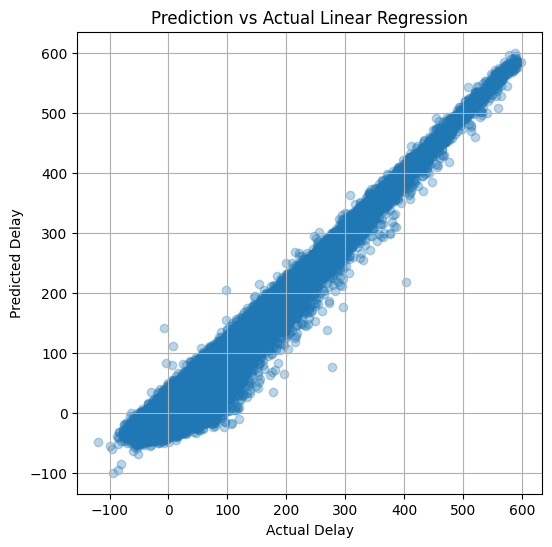

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(
    pdf["ARR_DELAY"],
    pdf["prediction"],
    alpha=0.3
)

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")

plt.title("Prediction vs Actual Linear Regression")

plt.grid()

plt.show()

In [23]:
coefficients = lr_model.coefficients.toArray()

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": coefficients
})

coef_df.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,DEP_DELAY,37.408492
0,DISTANCE,18.182907
3,TAXI_OUT,7.701614
4,TAXI_IN,4.573627
9,AIRLINE_DELAY_RATE,0.913745
11,PREVIOUS_FLIGHT_DELAY,0.411663
5,Hour,0.053291
7,Month,0.046715
6,DayOfWeek,0.040355
8,AIRPORT_DELAY_RATE,-0.128758


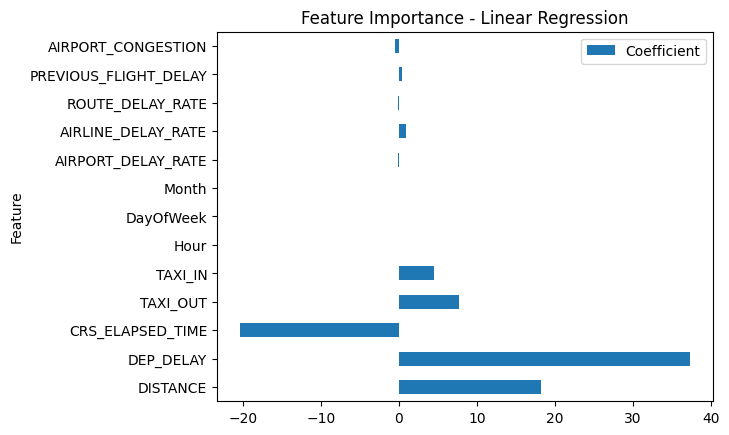

In [24]:
coef_df.plot(
    x="Feature",
    y="Coefficient",
    kind="barh"
)

plt.title("Feature Importance - Linear Regression")
plt.show()

# Random Forest Regressor

In [ ]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_df = assembler.transform(train_df)
test_df = assembler.transform(test_df)

In [26]:
from pyspark.ml.regression import RandomForestRegressor
rf = RandomForestRegressor(
    labelCol="ARR_DELAY",
    featuresCol="features",
    numTrees=30,
    maxDepth=6,
    maxBins=32,
    seed=42
)

rf_model = rf.fit(train_df)

26/03/16 22:38:48 WARN MemoryStore: Not enough space to cache rdd_895_7 in memory! (computed 19.2 MiB so far)
26/03/16 22:38:48 WARN BlockManager: Persisting block rdd_895_7 to disk instead.
26/03/16 22:38:48 WARN MemoryStore: Not enough space to cache rdd_895_0 in memory! (computed 28.8 MiB so far)
26/03/16 22:38:48 WARN BlockManager: Persisting block rdd_895_0 to disk instead.
26/03/16 22:38:49 WARN MemoryStore: Not enough space to cache rdd_895_5 in memory! (computed 19.2 MiB so far)
26/03/16 22:38:49 WARN BlockManager: Persisting block rdd_895_5 to disk instead.
26/03/16 22:38:49 WARN MemoryStore: Not enough space to cache rdd_895_1 in memory! (computed 28.8 MiB so far)
26/03/16 22:38:49 WARN MemoryStore: Not enough space to cache rdd_895_4 in memory! (computed 28.8 MiB so far)
26/03/16 22:38:49 WARN BlockManager: Persisting block rdd_895_4 to disk instead.
26/03/16 22:38:49 WARN BlockManager: Persisting block rdd_895_1 to disk instead.
26/03/16 22:38:49 WARN MemoryStore: Not enoug

In [27]:
predictions = rf_model.transform(test_df)

predictions.select(
    "ARR_DELAY",
    "prediction"
).show(10)

+---------+-------------------+
|ARR_DELAY|         prediction|
+---------+-------------------+
|     -7.0| -9.591576466571512|
|     -3.0|-12.607754205363316|
|      1.0| -8.170928253995001|
|     -4.0|-12.259070722155162|
|      5.0|-1.9643001828253444|
|    143.0| 154.19233360369486|
|     -6.0| -9.788422704457624|
|    -19.0| -11.79743154130897|
|    -22.0|-11.092722355818557|
|    -31.0|-11.228164697665553|
+---------+-------------------+
only showing top 10 rows


In [28]:
rmse_eval = RegressionEvaluator(
    labelCol="ARR_DELAY",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = rmse_eval.evaluate(predictions)
print("RMSE:", rmse)

mae_eval = RegressionEvaluator(
    labelCol="ARR_DELAY",
    predictionCol="prediction",
    metricName="mae"
)

mae = mae_eval.evaluate(predictions)
print("MAE:", mae)

r2_eval = RegressionEvaluator(
    labelCol="ARR_DELAY",
    predictionCol="prediction",
    metricName="r2"
)

r2 = r2_eval.evaluate(predictions)
print("R2:", r2)

RMSE: 18.719432324715935


MAE: 10.342574261660126


R2: 0.7811923213868699


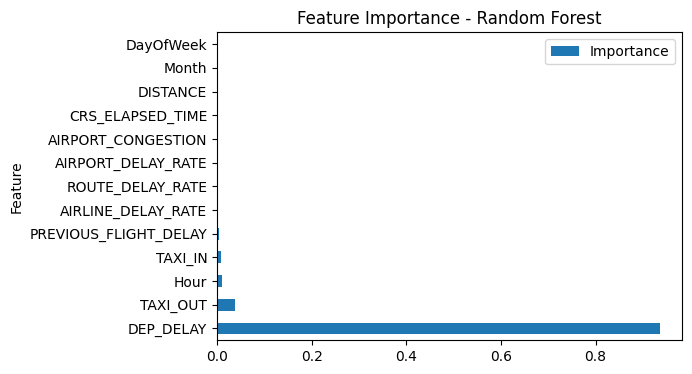

In [29]:
importances = rf_model.featureImportances

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances.toArray()
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df
importance_df.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(6,4)
)

plt.title("Feature Importance - Random Forest")
plt.show()

In [30]:
pdf = predictions.select(
    "ARR_DELAY",
    "prediction"
).toPandas()

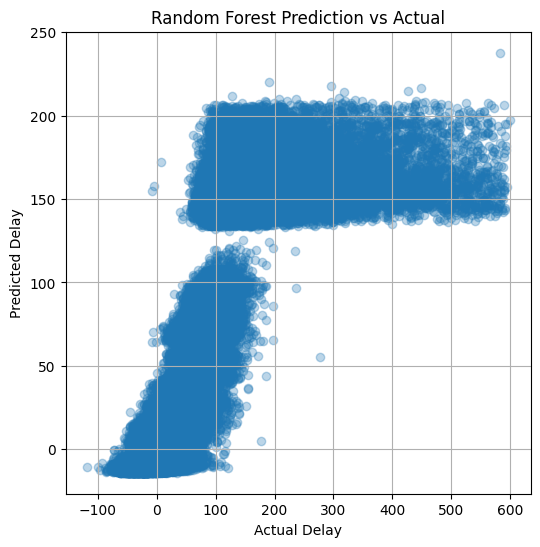

In [31]:
plt.figure(figsize=(6,6))

plt.scatter(
    pdf["ARR_DELAY"],
    pdf["prediction"],
    alpha=0.3
)

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")

plt.title("Random Forest Prediction vs Actual")

plt.grid()
plt.show()

In [32]:
predictions.withColumn(
    "error",
    F.abs(F.col("ARR_DELAY") - F.col("prediction"))
).orderBy(F.col("error").desc()).show(10)

+-------+------------+------+----------+----+--------+---------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+---------+-----+-------+---------------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+--------------------+--------------------+-------------------+-------------------+-------------------+------------------+------------------+
|  ROUTE|AIRLINE_CODE|ORIGIN|   FL_DATE|Hour|DOT_CODE|FL_NUMBER|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|DayOfWeek|Month|DELAYED|PREVIOUS_FLIGHT_DELAY|AIRPORT_CONGESTION|    AVG